In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import webbrowser
import os

nltk.download('vader_lexicon')

apps_df = pd.read_csv(r'C:\\Users\\Dell\\Downloads\\Play Store Data.csv')
reviews_df = pd.read_csv(r'C:\\Users\\Dell\\Downloads\\User Reviews.csv')

apps_df = apps_df.dropna(subset=['Rating'])
for column in apps_df.columns :
    apps_df[column].fillna(apps_df[column].mode()[0],inplace=True)
apps_df.drop_duplicates(inplace=True)
apps_df=apps_df=apps_df[apps_df['Rating']<=5]
reviews_df.dropna(subset=['Translated_Review'],inplace=True)

apps_df['Installs']=apps_df['Installs'].str.replace(',','').str.replace('+','').astype(int)
apps_df['Price']=apps_df['Price'].str.replace('$','').astype(float)

sia = SentimentIntensityAnalyzer()

reviews_df['Sentiment_Score']=reviews_df['Translated_Review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

merged_df=pd.merge(apps_df,reviews_df,on='App',how='inner')

def convert_size(size):
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))/1024
    else:
        return np.nan
apps_df['Size']=apps_df['Size'].apply(convert_size)

apps_df['Log_Installs']=np.log(apps_df['Installs'])

apps_df['Reviews']=apps_df['Reviews'].astype(int)

apps_df['Log_Reviews']=np.log(apps_df['Reviews'])

apps_df['Revenue']=apps_df['Price']*apps_df['Installs']

apps_df['Last Updated']=pd.to_datetime(apps_df['Last Updated'],errors='coerce')

apps_df['Year']=apps_df['Last Updated'].dt.year


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\Dell\AppData\Local\Temp\ipykernel_6012\1124471914.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps_df[column].fillna(apps_df[column].mode()[0],inplace=True)


In [2]:
html_files_path = './plots'
os.makedirs(html_files_path, exist_ok=True)
plot_containers = ''

def save_plot_as_html(fig, filename, insight):
    global plot_containers
    filepath = os.path.join(html_files_path, filename)
    html_content = pio.to_html(fig, full_html=False, include_plotlyjs='inline')
    plot_containers += f"""
    <div class="plot-container" id="{filename}" onclick="openPlot('{filename}')">
        <div class="plot">{html_content}</div>
        <div class="insights">{insight}</div>
    </div>
    """
    fig.write_html(filepath, full_html=False, include_plotlyjs='inline')

plot_width = 900
plot_height = 500
plot_bg_color = '#ffffff'  
text_color = '#333333'     
title_font = {'size': 20, 'color': text_color}
axis_font = {'size': 14}


In [3]:
#Task 1 

import plotly.express as px

def rating_group(rating):
    if rating <= 2:
        return '1–2'
    elif rating <= 4:
        return '3–4'
    else:
        return '4–5'

merged_df['Rating_Group'] = merged_df['Rating'].apply(rating_group)

merged_df['Sentiment'] = merged_df['Sentiment_Score'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
)

merged_df['Reviews'] = pd.to_numeric(merged_df['Reviews'], errors='coerce')

filtered = merged_df[merged_df['Reviews'] > 1000]


top5 = (
    filtered.groupby('Category')['Reviews']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

filtered_top5 = filtered[filtered['Category'].isin(top5)]

grouped = (
    filtered_top5.groupby(['Category', 'Rating_Group', 'Sentiment'])
    .size()
    .reset_index(name='Count')
)

pivot = grouped.pivot_table(
    index=['Category', 'Rating_Group'],
    columns='Sentiment',
    values='Count',
    fill_value=0
).reset_index()

fig1 = px.bar(
    grouped,
    x='Category',
    y='Count',
    color='Sentiment',
    barmode='stack',
    facet_col='Rating_Group',
    title="Figure 1: Sentiment Distribution — Top 5 Categories, Segmented by Rating Group",
    color_discrete_map={'Negative': 'red', 'Neutral': 'grey', 'Positive': 'green'}
)
fig1.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font=dict(color=text_color, size=axis_font['size']),
    title_font=title_font,
    width=plot_width + 300,
    height=plot_height + 100,
    xaxis=dict(title='Category'),
    yaxis=dict(title='Review Count')
)


fig1.show()

insight_task1 = """
This chart shows how user sentiments (positive, neutral, negative) are distributed
within different rating groups across the top 5 app categories. 
It helps understand whether higher-rated apps tend to receive more positive reviews 
compared to lower-rated ones.
"""

save_plot_as_html(fig1, "fig1_stacked_sentiment.html", insight_task1)


In [4]:
# Task 2 
import plotly.graph_objects as go
from datetime import datetime
import pytz

apps_df['Android Ver'] = apps_df['Android Ver'].astype(str).str.extract(r'(\d+\.\d+)')
apps_df['Android Ver'] = pd.to_numeric(apps_df['Android Ver'], errors='coerce')

filtered = apps_df[
    (apps_df['Installs'] >= 10000) &
    (apps_df['Revenue'] >= 10000) &
    (apps_df['Android Ver'] > 4.0) &
    (apps_df['Size'] > 15) &
    (apps_df['Content Rating'] == 'Everyone') &
    (apps_df['App'].str.len() <= 30)
]

top3 = (
    filtered.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)

filtered_top3 = filtered[filtered['Category'].isin(top3)]

grouped2 = (
    filtered_top3.groupby('Type').agg({
        'Installs': 'mean',
        'Revenue': 'mean'
    }).reset_index()
)

now = datetime.now(pytz.timezone('Asia/Kolkata'))

if 13 <= now.hour < 14:
    fig2 = go.Figure()

    fig2.add_trace(
        go.Bar(
            x=grouped2['Type'],
            y=grouped2['Installs'],
            name='Average Installs',
            yaxis='y1',
            marker_color='skyblue'
        )
    )

    fig2.add_trace(
        go.Scatter(
            x=grouped2['Type'],
            y=grouped2['Revenue'],
            name='Average Revenue',
            mode='lines+markers',
            yaxis='y2',
            marker=dict(color='orange')
        )
    )

    fig2.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font=dict(color=text_color, size=axis_font['size']),
    title_font=title_font,
    width=plot_width,
    height=plot_height,
    xaxis=dict(title='App Type (Free vs Paid)'),
    yaxis=dict(title='Average Installs'),
    yaxis2=dict(
        title='Average Revenue',
        overlaying='y',
        side='right'
    )
)

    fig2.show()

    insight_task2 = """
    This dual-axis chart compares the average installs and revenue between free and paid apps 
    in the top 3 app categories. It highlights how free apps typically achieve higher installs, 
    while paid apps generate direct revenue.
    """

    save_plot_as_html(fig2, "fig2_dual_axis_installs_revenue.html", insight_task2)
else:
    print("⏰ Outside 1–2 PM IST — Figure 2 not shown.")


⏰ Outside 1–2 PM IST — Figure 2 not shown.


In [5]:
# Task 3
from datetime import datetime
import pytz
import plotly.graph_objects as go

filtered3 = apps_df[
    (apps_df['Rating'] >= 4.0) &
    (apps_df['Size'] >= 10) &
    (apps_df['Last Updated'].dt.month == 1)
].copy()

print("✅ Filtered shape:", filtered3.shape)

top10 = (
    filtered3.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

filtered_top10 = filtered3[filtered3['Category'].isin(top10)]

print("✅ Top 10 Categories:", top10)

grouped3 = (
    filtered_top10.groupby('Category')
    .agg({'Rating': 'mean', 'Reviews': 'sum'})
    .reset_index()
)

print("✅ Grouped3:\n", grouped3)


now = datetime.now(pytz.timezone('Asia/Kolkata'))

if 15 <= now.hour < 17 and not grouped3.empty:

    fig3 = go.Figure()

    fig3.add_trace(go.Bar(
        x=grouped3['Category'],
        y=grouped3['Rating'],
        name='Average Rating'
    ))

    fig3.add_trace(go.Bar(
        x=grouped3['Category'],
        y=grouped3['Reviews'],
        name='Total Reviews'
    ))

    fig3.update_layout(
    barmode='group',
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font=dict(color=text_color, size=axis_font['size']),
    title_font=title_font,
    width=plot_width,
    height=plot_height,
    xaxis=dict(title='Category', tickangle=-30),
    yaxis=dict(title='Values')
)


    fig3.show()

    insight_task3 = """
    This grouped bar chart shows both the average rating and total review count 
    for the top 10 app categories by installs. It reveals which categories maintain high ratings 
    while also attracting significant user engagement.
    """


    save_plot_as_html(fig3, "fig3_grouped_bar_chart.html", insight_task3)

else:
    print("⏰ Outside 3–5 PM IST or no data left — Task 3 not shown.")


✅ Filtered shape: (127, 17)
✅ Top 10 Categories: ['FAMILY', 'SPORTS', 'GAME', 'ENTERTAINMENT', 'PERSONALIZATION', 'PHOTOGRAPHY', 'LIFESTYLE', 'EDUCATION', 'TOOLS', 'TRAVEL_AND_LOCAL']
✅ Grouped3:
            Category    Rating  Reviews
0         EDUCATION  4.400000    57645
1     ENTERTAINMENT  4.300000   869111
2            FAMILY  4.395455  4544623
3              GAME  4.313333  2397589
4         LIFESTYLE  4.380000    42809
5   PERSONALIZATION  4.475000   155996
6       PHOTOGRAPHY  4.150000   563720
7            SPORTS  4.342857  1982017
8             TOOLS  4.200000     8010
9  TRAVEL_AND_LOCAL  4.100000      974
⏰ Outside 3–5 PM IST or no data left — Task 3 not shown.


✅ Filtered shape: (6586, 18)
✅ Top 5 Categories: ['PRODUCTIVITY', 'TOOLS', 'FAMILY', 'PHOTOGRAPHY', 'TRAVEL_AND_LOCAL']
✅ Grouped4 shape: (5, 4)
✅ Sample:
          Country          Category     Installs  Highlight
0  United States            FAMILY  10041130590       True
1  United States       PHOTOGRAPHY   9721243130       True
2  United States      PRODUCTIVITY  12463070180       True
3  United States             TOOLS  11450724500       True
4  United States  TRAVEL_AND_LOCAL   6361859300       True


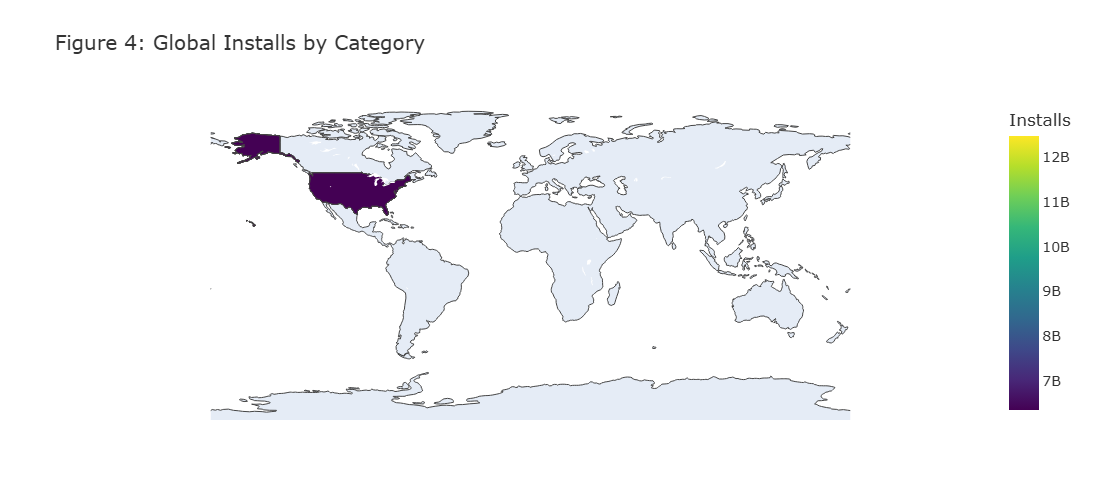

In [15]:
# ✅ TASK 4 — Choropleth Map for Top 5 Categories (6 PM to 8 PM IST)
from datetime import datetime
import pytz
import plotly.express as px

# Set dummy country if not available
if 'Country' not in apps_df.columns:
    apps_df['Country'] = 'United States'  # fallback/default country

# ➤ Filter out categories starting with A, C, G, S
filtered4 = apps_df[~apps_df['Category'].str.startswith(('A', 'C', 'G', 'S'))].copy()
print("✅ Filtered shape:", filtered4.shape)

# ➤ Get top 5 categories by total installs
top5 = (
    filtered4.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
print("✅ Top 5 Categories:", top5)

# ➤ Keep only top 5 categories
filtered_top5 = filtered4[filtered4['Category'].isin(top5)].copy()

# ➤ Highlight if installs > 1 million
filtered_top5['Highlight'] = filtered_top5['Installs'] > 1_000_000

# ➤ Group by Country + Category
grouped4 = (
    filtered_top5.groupby(['Country', 'Category'])
    .agg({'Installs': 'sum', 'Highlight': 'max'})
    .reset_index()
)
print("✅ Grouped4 shape:", grouped4.shape)
print("✅ Sample:\n", grouped4.head())

# ➤ Check time window
now = datetime.now(pytz.timezone('Asia/Kolkata'))

if 11 <= now.hour < 20 and not grouped4.empty:
    fig4 = px.choropleth(
        grouped4,
        locations='Country',
        locationmode='country names',
        color='Installs',
        hover_name='Category',
        color_continuous_scale='Viridis',
        title="Figure 4: Global Installs by Category"
    )

    # ➤ Update layout
    fig4.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='equirectangular'
        ),
        plot_bgcolor=plot_bg_color,
        paper_bgcolor=plot_bg_color,
        font=dict(color=text_color, size=axis_font['size']),
        title_font=title_font,
        width=plot_width,
        height=plot_height
    )

    fig4.show()

    insight_task4 = """
    This interactive map displays global installs for the top 5 app categories, 
    highlighting regions and categories with the highest user reach. 
    Categories with over 1 million installs are emphasized to indicate major markets.
    """

    # ➤ Save as HTML
    save_plot_as_html(fig4, "fig4_choropleth_map.html", insight_task4)

else:
    print("⏰ Outside 6–8 PM IST or no data available — Task 4 not shown.")


In [7]:
# Task 5 
from textblob import TextBlob
from datetime import datetime
import pytz
import plotly.express as px

if 'Subjectivity' not in reviews_df.columns:
    reviews_df['Subjectivity'] = reviews_df['Translated_Review'].apply(
        lambda x: TextBlob(str(x)).sentiment.subjectivity
    )

merged5 = pd.merge(apps_df, reviews_df[['App', 'Subjectivity']], on='App', how='left')

filtered5 = merged5[
    (merged5['Rating'] > 3.5) &
    (merged5['Category'].isin(['GAME', 'Beauty', 'Business', 'Comics', 'Communication',
                               'Dating', 'Entertainment', 'Social', 'Event'])) &
    (merged5['Reviews'] > 500) &
    (~merged5['App'].str.contains('S', case=False, na=False)) &
    (merged5['Subjectivity'] > 0.5) &
    (merged5['Installs'] > 50_000)
].copy()

print("✅ Filtered shape:", filtered5.shape)

def translate_category(cat):
    if cat == 'Beauty':
        return 'सौंदर्य'  
    elif cat == 'Business':
        return 'வணிகம்'  
    elif cat == 'Dating':
        return 'Verabredung' 
    else:
        return cat

filtered5['Category_Label'] = filtered5['Category'].apply(translate_category)

now = datetime.now(pytz.timezone('Asia/Kolkata'))

if 17 <= now.hour < 19 and not filtered5.empty:

    fig5 = px.scatter(
        filtered5,
        x='Size',
        y='Rating',
        size='Installs',
        color='Category_Label',
        hover_name='App',
        title="Figure 5: Bubble Chart - Size vs Rating (Bubble = Installs)",
    )

    fig5.for_each_trace(
        lambda t: t.update(marker=dict(color='pink'))
        if 'GAME' in t.name.upper() or 'Game' in t.name else ()
    )

    fig5.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font=dict(color=text_color, size=axis_font['size']),
    title_font=title_font,
    width=plot_width,
    height=plot_height,
    xaxis=dict(title='App Size (MB)'),
    yaxis=dict(title='Average Rating')
)


    fig5.show()

    insight_task5 = """
    This bubble chart visualizes how app size relates to average rating, 
    with bubble size representing the number of installs. 
    It highlights whether larger apps tend to achieve better ratings and bigger audiences.
    The Game category is emphasized in pink, and select categories are translated 
    for regional context.
    """


    save_plot_as_html(fig5, "fig5_bubble_chart.html", insight_task5)

else:
    print("⏰ Outside 5–7 PM IST or no data left — Task 5 not shown.")


✅ Filtered shape: (3181, 19)
⏰ Outside 5–7 PM IST or no data left — Task 5 not shown.


In [8]:
# Task 6
from datetime import datetime
import pytz
import plotly.graph_objects as go

filtered6 = apps_df[
    (~apps_df['App'].str.startswith(('X', 'Y', 'Z'), na=False)) &
    (apps_df['Category'].str.startswith(('E', 'C', 'B'))) &
    (apps_df['Reviews'] > 500) &
    (~apps_df['App'].str.contains('S', case=False, na=False))
].copy()

print("✅ Filtered shape:", filtered6.shape)

def translate_category(cat):
    if cat == 'Beauty':
        return 'सौंदर्य' 
    elif cat == 'Business':
        return 'வணிகம்'   
    elif cat == 'Dating':
        return 'Verabredung'
    else:
        return cat

filtered6['Category_Label'] = filtered6['Category'].apply(translate_category)

filtered6['YearMonth'] = filtered6['Last Updated'].dt.to_period('M')
grouped6 = (
    filtered6.groupby(['YearMonth', 'Category_Label'])['Installs']
    .sum()
    .reset_index()
    .sort_values(['Category_Label', 'YearMonth'])
)

print("✅ Grouped6:\n", grouped6.head())

grouped6['Pct_Change'] = (
    grouped6.groupby('Category_Label')['Installs']
    .pct_change()
    .fillna(0)
)

print("✅ Grouped6 with % Change:\n", grouped6.head(10))

now = datetime.now(pytz.timezone('Asia/Kolkata'))

if 18 <= now.hour < 21 and not grouped6.empty:

    fig6 = go.Figure()

    categories = grouped6['Category_Label'].unique()

    for cat in categories:
        cat_data = grouped6[grouped6['Category_Label'] == cat]

        fig6.add_trace(go.Scatter(
            x=cat_data['YearMonth'].astype(str),
            y=cat_data['Installs'],
            mode='lines',
            name=cat
        ))

        highlight = cat_data[cat_data['Pct_Change'] > 0.2]
        fig6.add_trace(go.Scatter(
            x=highlight['YearMonth'].astype(str),
            y=highlight['Installs'],
            mode='lines',
            line=dict(width=0),
            showlegend=False,
            fill='tozeroy',
            fillcolor='rgba(255, 0, 0, 0.2)'  
        ))

    fig6.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font=dict(color=text_color, size=axis_font['size']),
    title_font=title_font,
    width=plot_width,
    height=plot_height,
    xaxis=dict(title='Date'),
    yaxis=dict(title='Total Installs')
)


    fig6.show()

    insight_task6 = """
    This time series shows how total installs have changed over time for selected app categories. 
    Periods where installs grew by more than 20% month-over-month are shaded, 
    indicating spikes in popularity or seasonal trends.
    """


    save_plot_as_html(fig6, "fig6_time_series.html", insight_task6)

else:
    print("⏰ Outside 6–9 PM IST or no data left — Task 6 not shown.")


✅ Filtered shape: (214, 18)
✅ Grouped6:
    YearMonth       Category_Label  Installs
46   2018-03               BEAUTY      5000
58   2018-06               BEAUTY   1000000
64   2018-07               BEAUTY   1000000
72   2018-08               BEAUTY    100000
5    2014-10  BOOKS_AND_REFERENCE    500000
✅ Grouped6 with % Change:
    YearMonth       Category_Label  Installs  Pct_Change
46   2018-03               BEAUTY      5000    0.000000
58   2018-06               BEAUTY   1000000  199.000000
64   2018-07               BEAUTY   1000000    0.000000
72   2018-08               BEAUTY    100000   -0.900000
5    2014-10  BOOKS_AND_REFERENCE    500000    0.000000
6    2014-11  BOOKS_AND_REFERENCE   5000000    9.000000
10   2015-07  BOOKS_AND_REFERENCE  10000000    1.000000
18   2016-06  BOOKS_AND_REFERENCE     60000   -0.994000
21   2016-08  BOOKS_AND_REFERENCE    100000    0.666667
27   2017-02  BOOKS_AND_REFERENCE    100000    0.000000
⏰ Outside 6–9 PM IST or no data left — Task 6 not sh